# Data Management — BBO Capstone

Load weekly results from the portal, update function data, and inspect statistics.
Run this after you receive results for a given week, then use **weekly_workflow.ipynb** for the next week.

## 1. Setup

In [7]:
import sys
from pathlib import Path
root = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(root))

from src.data import (
    FunctionData,
    DATA_DIR,
    load_results,
    load_latest_results,
    initialize_all_weeks,
    update_all_functions_with_results,
    update_function_with_result,
)
from src.utils import display_competition_summary, plot_progress, analyze_weekly_performance

print("✓ Imports ready")

✓ Imports ready


## 2. Load functions and historical data

In [8]:
functions = {i: FunctionData(i, data_dir=DATA_DIR) for i in range(1, 9)}
num_weeks = initialize_all_weeks(functions)
print(f"✓ Loaded {len(functions)} functions with {num_weeks} weeks of history")

INITIALIZING FUNCTIONS FROM HISTORICAL DATA
Source: /home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/data/results
Loading weeks: [1, 2, 3, 4, 5, 6]

✓ Loaded Week 1 from /home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/data/results/week_1
✓ Week 1: Updated 8 functions
✓ Loaded Week 2 from /home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/data/results/week_2
✓ Week 2: Updated 8 functions
✓ Loaded Week 3 from /home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/data/results/week_3
✓ Week 3: Updated 8 functions
✓ Loaded Week 4 from /home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/data/results/week_4
✓ Week 4: Updated 8 functions
✓ Loaded Week 5 from /home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/data/results/week_5
✓ Week 5: Updated 8 functions
✓ Loaded Week 6 from /home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/data/results/

## 3. Load new week results

After you receive results from the portal, save them into `data/results/week_N/` (create the folder if needed):
- `inputs.txt` — one list of 8 arrays (or append to existing format)
- `outputs.txt` — one list of 8 floats

Then run the cell below to load the **latest** week (or change `week_index`).

In [9]:
# Load latest week's results (or set week_index: 0=week 1, 1=week 2, -1=latest)
inputs_dict, outputs_dict, week_num = load_latest_results()
print(f"Week {week_num}: {len(inputs_dict)} functions")

✓ Loaded Week 6 from /home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/data/results/week_6
Week 6: 8 functions


## 4. Update all functions with new results

In [10]:
# Update in-memory and save to data/function_N/week_W_inputs.npy and week_W_outputs.npy
update_all_functions_with_results(functions, inputs_dict, outputs_dict, week_num, save=True)

UPDATING ALL FUNCTIONS WITH WEEK 6 RESULTS

✓ Function 1 (2D): y=0.000000, best=0.000000
    Total samples: 17

✓ Function 2 (2D): y=0.397502, best=0.620709
    Total samples: 17

✓ Function 3 (3D): y=-0.026702, best=-0.005532
    Total samples: 22

✓ Function 4 (4D): y=0.636948, best=0.661171
    Total samples: 37

✓ Function 5 (4D): y=8662.405001, best=8662.405001
    Total samples: 27

✓ Function 6 (5D): y=-0.519508, best=-0.519508
    Total samples: 27

✓ Function 7 (6D): y=2.284265, best=2.468092
    Total samples: 37

✓ Function 8 (8D): y=9.947488, best=9.947488
    Total samples: 47

✓ Updated 8 functions. New bests: 0


[{'func_id': 1,
  'n_dims': 2,
  'y': 2.6752879910742468e-09,
  'best_y': np.float64(2.6752879910742468e-09),
  'is_new_best': np.False_,
  'improvement': 0.0,
  'n_samples': 17},
 {'func_id': 2,
  'n_dims': 2,
  'y': 0.3975016656030499,
  'best_y': np.float64(0.6207093868270447),
  'is_new_best': np.False_,
  'improvement': 0.0,
  'n_samples': 17},
 {'func_id': 3,
  'n_dims': 3,
  'y': -0.026702112742567435,
  'best_y': np.float64(-0.005531568722558512),
  'is_new_best': np.False_,
  'improvement': 0.0,
  'n_samples': 22},
 {'func_id': 4,
  'n_dims': 4,
  'y': 0.636947881810642,
  'best_y': np.float64(0.6611706964725319),
  'is_new_best': np.False_,
  'improvement': 0.0,
  'n_samples': 37},
 {'func_id': 5,
  'n_dims': 4,
  'y': 8662.405001248297,
  'best_y': np.float64(8662.405001248297),
  'is_new_best': np.False_,
  'improvement': 0.0,
  'n_samples': 27},
 {'func_id': 6,
  'n_dims': 5,
  'y': -0.5195079796311365,
  'best_y': np.float64(-0.5195079796311365),
  'is_new_best': np.False

## 5. Analyze week performance (optional)

In [11]:
analysis = analyze_weekly_performance(week_num, functions)

ANALYZING WEEK 6 PERFORMANCE
✓ Loaded Week 6 from /home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/data/results/week_6
Func   Dims   Old Best     New Value    Change       Status         
--------------------------------------------------------------------------------
1      2      0.000000     0.000000        +0.000000 → Stagnant     
2      2      0.620709     0.397502        -0.223208 ✗ Declining    
3      3      -0.005532    -0.026702       -0.021171 ✗ Declining    
4      4      0.661171     0.636948        -0.024223 ✗ Declining    
5      4      8662.405001  8662.405001     +0.000000 → Stagnant     
6      5      -0.519508    -0.519508       +0.000000 → Stagnant     
7      6      2.468092     2.284265        -0.183826 ✗ Declining    
8      8      9.947488     9.947488        +0.000000 → Stagnant     


## 6. Summary and progress plots

COMPETITION SUMMARY
Total weekly submissions: 0
Best values by function:
--------------------------------------------------------------------------------
Function 1 (2D): 0.000000 (+0.000000, 17 samples)
Function 2 (2D): 0.620709 (+0.081713, 17 samples)
Function 3 (3D): -0.005532 (+0.106591, 22 samples)
Function 4 (4D): 0.661171 (+22.769458, 37 samples)
Function 5 (4D): 8662.405001 (+8597.961561, 27 samples)
Function 6 (5D): -0.519508 (+0.194757, 27 samples)
Function 7 (6D): 2.468092 (+1.863659, 37 samples)
Function 8 (8D): 9.947488 (+2.548767, 47 samples)


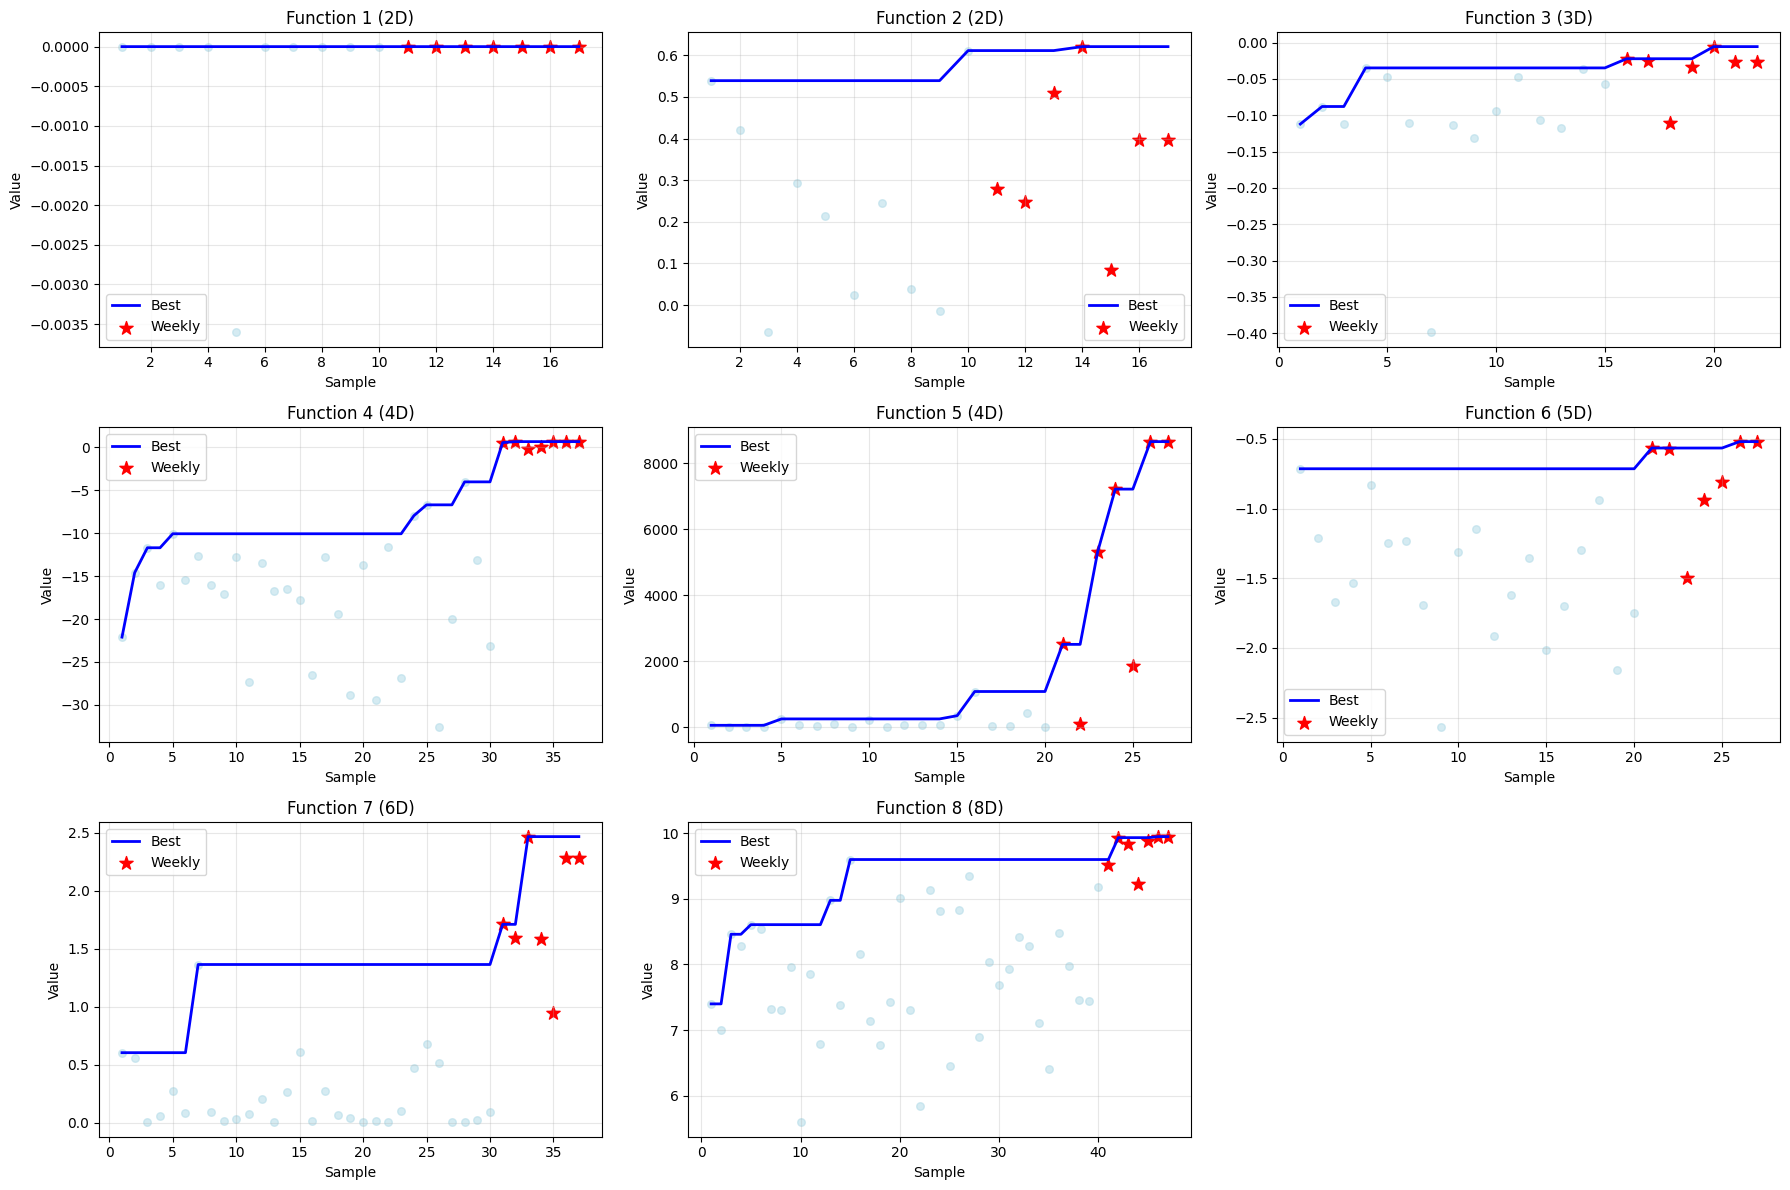

In [12]:
display_competition_summary(functions)
plot_progress(functions)

## 7. Manual single-function update (optional)

If you need to update one function by hand (e.g. corrected value):

In [13]:
# update_function_with_result(functions, func_id=1, x=np.array([0.5, 0.5]), y=1.23, week=4, save=True)